The EDA (exploratory data analysis) conducted here aims to understand what the dataset contains (`day`, `tick`, `logprice`) and how it is structured. <br>
We also check basic data quality (duplicate timestamps, tick ordering within each day, and possible gaps/irregular sampling). <br>
Finally, we show what can be derived from these ticks for the other notebooks: the daily series (R_d) and (RV_d), and the intraday cumulative curves (Y_n(t)).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 120

# 1) Load + quick look


In [3]:

def load_ticks(path: str) -> pd.DataFrame:
    # Read + light cleaning (lowercase columns, numeric values)
    df = pd.read_csv(path, low_memory=False)
    df.columns = [str(c).strip().lower() for c in df.columns]
    df = df[["day", "tick", "logprice"]]

    df["day"] = pd.to_numeric(df["day"], errors="coerce").astype("Int64")
    df["tick"] = pd.to_numeric(df["tick"], errors="coerce")
    df["logprice"] = pd.to_numeric(df["logprice"], errors="coerce")

    df = df.dropna(subset=["day", "tick", "logprice"]).reset_index(drop=True)
    df["day"] = df["day"].astype(int)

    # Important: sort by day then tick
    df = df.sort_values(["day", "tick"]).reset_index(drop=True)
    return df

path = "out28.csv"  # adapt if needed
df = load_ticks(path)

In [4]:
print("Number of rows (ticks):", len(df))
print("Number of days:", df["day"].nunique())
print("Tick range:", (df["tick"].min(), df["tick"].max()))
print("\nFirst rows:")
print(df.head())

Number of rows (ticks): 1984163
Number of days: 754
Tick range: (4.2735042735042735e-05, 1.0)

First rows:
   day      tick  logprice
0    1  0.002222  3.749975
1    1  0.002265  3.749504
2    1  0.002350  3.749504
3    1  0.002393  3.749739
4    1  0.002436  3.750680


We have about **2.0 million ticks** over **754 days**. The `tick` variable runs from ~0 to 1, which suggests it is a normalized intraday time index.


# 2) How many ticks per day?

In [5]:
ticks_per_day = df.groupby("day").size()
print(ticks_per_day.describe())

count     754.000000
mean     2631.515915
std       695.902645
min      1017.000000
25%      2151.000000
50%      2546.000000
75%      2969.500000
max      6629.000000
dtype: float64


On average there are about **2630 ticks per day**, but it varies a lot (from ~**1000** to ~**6600**). So some days are much more active or more densely sampled than others.


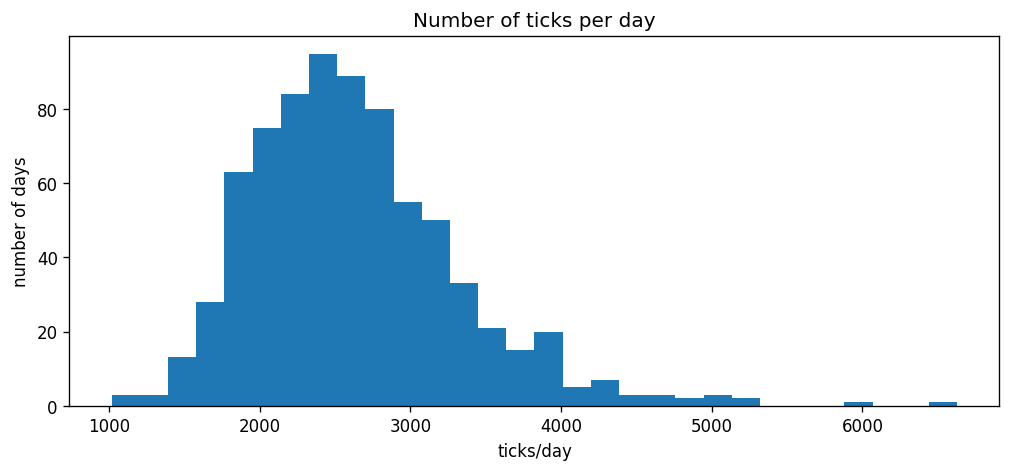

In [6]:
plt.figure()
plt.hist(ticks_per_day, bins=30)
plt.title("Number of ticks per day")
plt.xlabel("ticks/day")
plt.ylabel("number of days")
plt.show()

The distribution is concentrated around roughly **2000–3000 ticks/day**, with a right tail. A few days have unusually many ticks, which could correspond to high-activity days.


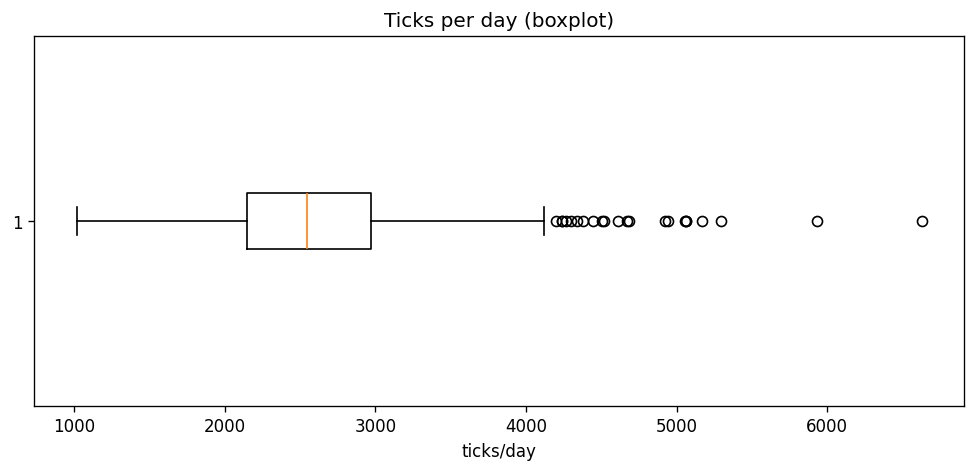

In [7]:
plt.figure()
plt.boxplot(ticks_per_day.values, vert=False)
plt.title("Ticks per day (boxplot)")
plt.xlabel("ticks/day")
plt.show()

The boxplot confirms the variability and highlights several **high-tick outliers**. Most days fall in a fairly stable range, but a handful of days are much more densely sampled.


In [8]:
# Intraday coverage: do we always start/end at similar ticks?
day_bounds = df.groupby("day")["tick"].agg(["min", "max"])
print("\n Intraday coverage (tick min / tick max per day) :")
print(day_bounds.describe())


 Intraday coverage (tick min / tick max per day) :
              min         max
count  754.000000  754.000000
mean     0.003191    0.994443
std      0.004417    0.050156
min      0.000043    0.538376
25%      0.000855    0.999957
50%      0.002350    0.999957
75%      0.004605    0.999957
max      0.097265    1.000000


Most days start close to 0 and end close to 1, which is what we want for full-day coverage. But the minimum of the daily end tick is around **0.54**, so some days look truncated (early close or missing end-of-day ticks).


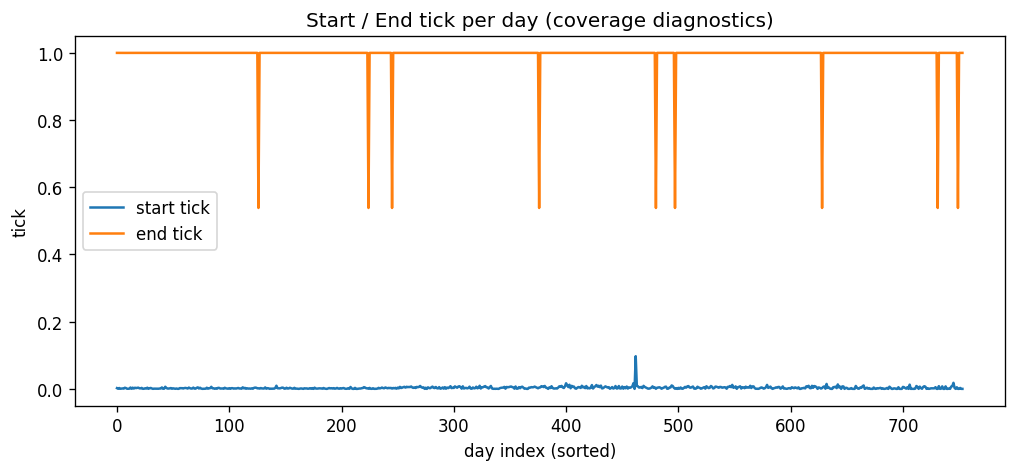

In [9]:
plt.figure()
plt.plot(day_bounds["min"].values, label="start tick")
plt.plot(day_bounds["max"].values, label="end tick")
plt.title("Start / End tick per day (coverage diagnostics)")
plt.xlabel("day index (sorted)")
plt.ylabel("tick")
plt.legend()
plt.show()

Start ticks are consistently very close to 0, which is good. End ticks are usually near 1, but the drops confirm there are a few days with shorter coverage.


# 3) Integrity: duplicates + are ticks properly ordered?


In [10]:
dup = df.duplicated(["day", "tick"]).sum()
print("Duplicates (day, tick):", dup)

Duplicates (day, tick): 0


There are **no duplicated (day, tick)** pairs, so we don’t have repeated timestamps within a day. That’s a good sign for building returns and intraday curves.


In [11]:
def count_non_increasing(group):
    # Count cases where tick does not strictly increase (diff <= 0)
    d = group["tick"].diff()
    return int((d.dropna() <= 0).sum())

In [12]:
mono_viol = df.groupby("day", group_keys=False).apply(count_non_increasing).sum()
print("\n Tick order :")
print("Total number of violations (non-increasing tick):", mono_viol)



 Tick order :
Total number of violations (non-increasing tick): 0


/tmp/ipython-input-1471092598.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mono_viol = df.groupby("day", group_keys=False).apply(count_non_increasing).sum()


Within each day, ticks are strictly increasing (no ordering violations). This is important because it means differences and cumulative curves are well-defined.


# 4) Sampling irregularity (Δtick)


In [13]:
df["dtick"] = df.groupby("day")["tick"].diff()
dtick = df["dtick"].dropna()

In [14]:
print("\ Δtick (time between two ticks) :")
print(dtick.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

\ Δtick (time between two ticks) :
count    1.983409e+06
mean     3.768280e-04
std      5.054138e-04
min      4.273504e-05
1%       4.273504e-05
5%       4.273504e-05
50%      2.136752e-04
95%      1.324786e-03
99%      2.435897e-03
max      9.068376e-02
Name: dtick, dtype: float64


<>:1: SyntaxWarning: invalid escape sequence '\ '
<>:1: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-3944331744.py:1: SyntaxWarning: invalid escape sequence '\ '
  print("\ Δtick (time between two ticks) :")


Δtick is usually very small (median around **2.1e-4**), but there are occasional much larger gaps (max around **9e-2**). So the sampling is clearly **irregular**, with some missing intervals.


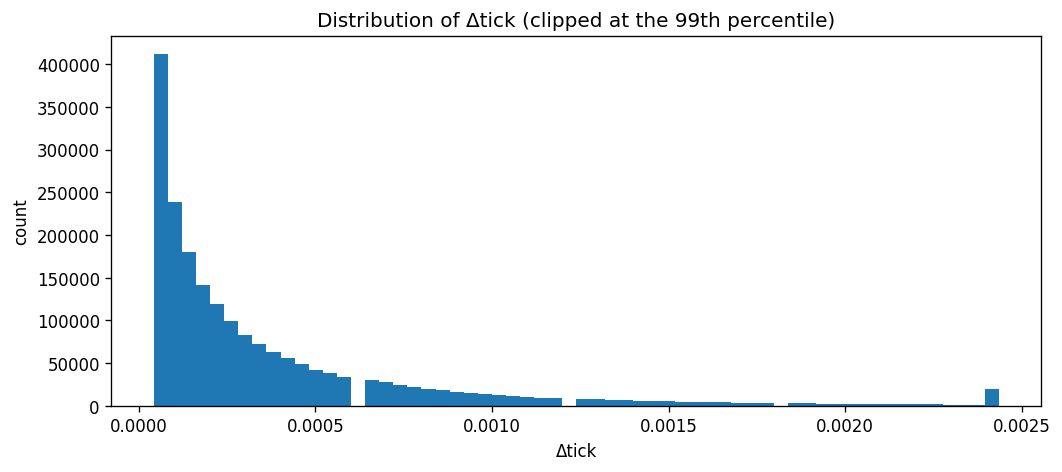

In [15]:
plt.figure()
# clip at 99% so large gaps do not crush the histogram
plt.hist(dtick.clip(upper=dtick.quantile(0.99)), bins=60)
plt.title("Distribution of Δtick (clipped at the 99th percentile)")
plt.xlabel("Δtick")
plt.ylabel("count")
plt.show()

The histogram is strongly right-skewed: most ticks arrive quickly, but there’s a long tail of larger gaps. This supports using a grid/interpolation step later (Topic 3) and being careful about uneven sampling.


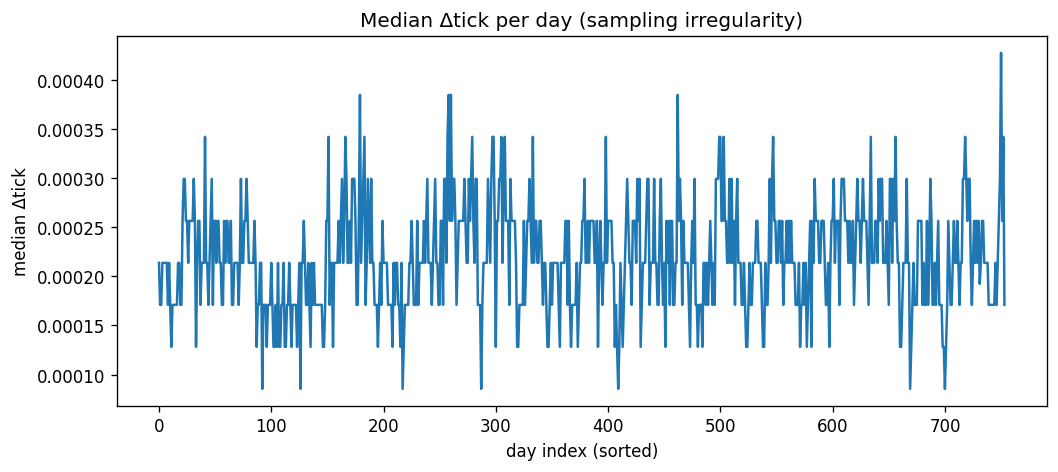

In [16]:
# Quick per-day summary: median Δtick
median_dtick = df.groupby("day")["dtick"].median()
plt.figure()
plt.plot(median_dtick.values)
plt.title("Median Δtick per day (sampling irregularity)")
plt.xlabel("day index (sorted)")
plt.ylabel("median Δtick")
plt.show()

The daily median Δtick fluctuates over time, meaning the sampling intensity changes from day to day. Spikes correspond to days where ticks are more spaced out on average (less frequent updates).


# 5) Intraday returns Δlogprice: size + quick outlier check


In [17]:
df["r_intraday"] = df.groupby("day")["logprice"].diff()
rintra = df["r_intraday"].dropna()

In [18]:
print("\nIntraday returns: Δlogprice :")
print(rintra.describe(percentiles=[0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]))



Intraday returns: Δlogprice :
count    1.983409e+06
mean     2.516144e-07
std      1.759302e-04
min     -5.666190e-03
0.1%    -8.962507e-04
1%      -4.838299e-04
5%      -2.596728e-04
50%      0.000000e+00
95%      2.587322e-04
99%      4.803742e-04
99.9%    8.923439e-04
max      7.829392e-03
Name: r_intraday, dtype: float64


Intraday returns are extremely centered around zero (mean ~ 0), and the **median is exactly 0**, which suggests many consecutive ticks have **no price change** (common in tick data). The tails are much heavier: the min/max are around **-0.0057 / 0.0078**, so rare jumps exist.


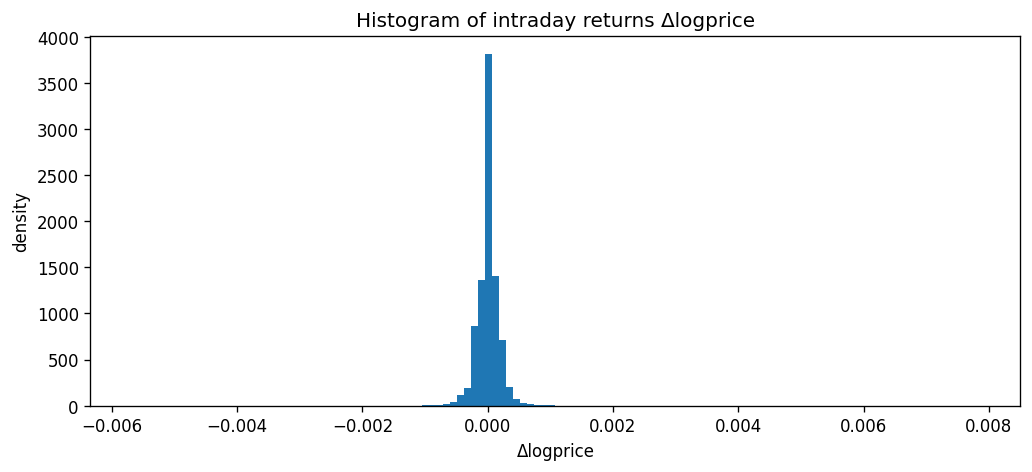

In [19]:
plt.figure()
plt.hist(rintra, bins=120, density=True)
plt.title("Histogram of intraday returns Δlogprice")
plt.xlabel("Δlogprice")
plt.ylabel("density")
plt.show()

The distribution is sharply peaked at 0 with relatively thin middle mass, and a few extreme values far from 0. In other words: **most ticks barely move**, but there are occasional **large jumps**.


In [34]:
# Look at the largest absolute moves (could be outlier / news / error)
k = 15
idx_top = rintra.abs().sort_values(ascending=False).head(k).index
top_moves = df.loc[idx_top, ["day", "tick", "r_intraday"]].copy()
top_moves["abs_r"] = top_moves["r_intraday"].abs()
top_moves = top_moves.sort_values("abs_r", ascending=False)

In [35]:
print(f"\n Top {k} largest intraday moves (|Δlogprice|) :")
print(top_moves)


 Top 15 largest intraday moves (|Δlogprice|) :
         day      tick  r_intraday     abs_r
581407   219  0.422521    0.007829  0.007829
581408   219  0.422607   -0.005666  0.005666
1138722  433  0.001325   -0.004719  0.004719
800370   311  0.077607    0.004713  0.004713
1907700  725  0.989658   -0.004375  0.004375
312177   119  0.001581   -0.004074  0.004074
1835318  701  0.006581    0.003439  0.003439
800371   311  0.079915   -0.003426  0.003426
502114   195  0.004786   -0.003423  0.003423
1503028  573  0.001923    0.003130  0.003130
288761   112  0.000897   -0.003100  0.003100
1764792  678  0.002222   -0.003087  0.003087
1927792  734  0.000214    0.003044  0.003044
676184   255  0.003632    0.003023  0.003023
222872    93  0.001624   -0.002958  0.002958


This table lists the biggest single-tick jumps, which are useful to sanity-check potential outliers or news moves. They are rare but large compared to typical tick changes, so they are worth keeping in mind for downstream volatility estimates.


# 6) Intraday volatility seasonality (U-shape type pattern)


In [22]:

# Idea: normalize intraday time within each day between 0 and 1,
# then bin (start -> end) and compute mean |r| and mean r^2.

def add_u(group):
    tmin, tmax = group["tick"].min(), group["tick"].max()
    if tmax == tmin:
        group["u"] = 0.0
    else:
        group["u"] = (group["tick"] - tmin) / (tmax - tmin)
    return group

In [23]:
tmp = df.dropna(subset=["r_intraday"]).copy()
tmp = tmp.groupby("day", group_keys=False).apply(add_u)

nbins = 20
tmp["ubin"] = pd.cut(tmp["u"], bins=nbins, labels=False, include_lowest=True)

season = tmp.groupby("ubin")["r_intraday"].agg(
    mean_abs=lambda x: np.mean(np.abs(x)),
    mean_sq=lambda x: np.mean(x**2),
    count="count",
).reset_index()

/tmp/ipython-input-722474972.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp = tmp.groupby("day", group_keys=False).apply(add_u)


In [24]:
print("\n Intraday volatility (by normalized time bin) :")
print(season.head())


 Intraday volatility (by normalized time bin) :
   ubin  mean_abs       mean_sq   count
0     0  0.000199  8.962434e-08  177319
1     1  0.000147  4.542611e-08  146178
2     2  0.000128  3.465783e-08  121275
3     3  0.000122  3.153258e-08  106974
4     4  0.000118  2.964511e-08   97317


By splitting the day into 20 normalized time bins, we can see how volatility changes from open to close. The first bins have higher average |r| and r², and the counts show we have plenty of observations in each bin.


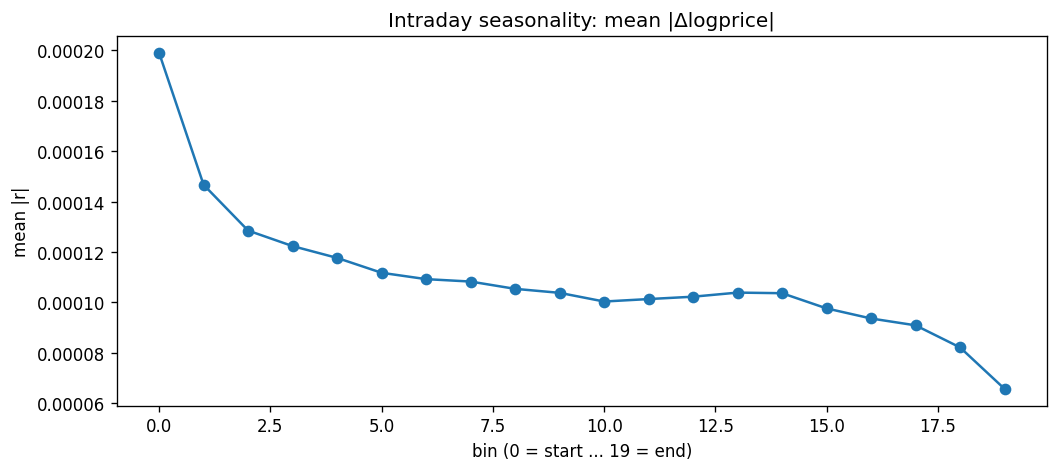

In [25]:

plt.figure()
plt.plot(season["ubin"], season["mean_abs"], marker="o")
plt.title("Intraday seasonality: mean |Δlogprice|")
plt.xlabel("bin (0 = start ... 19 = end)")
plt.ylabel("mean |r|")
plt.show()

Volatility is highest at the **start of the day** and generally declines as we move toward the end. To read it: each point is the average absolute return in that time slice (bin 0 = open, bin 19 = close).


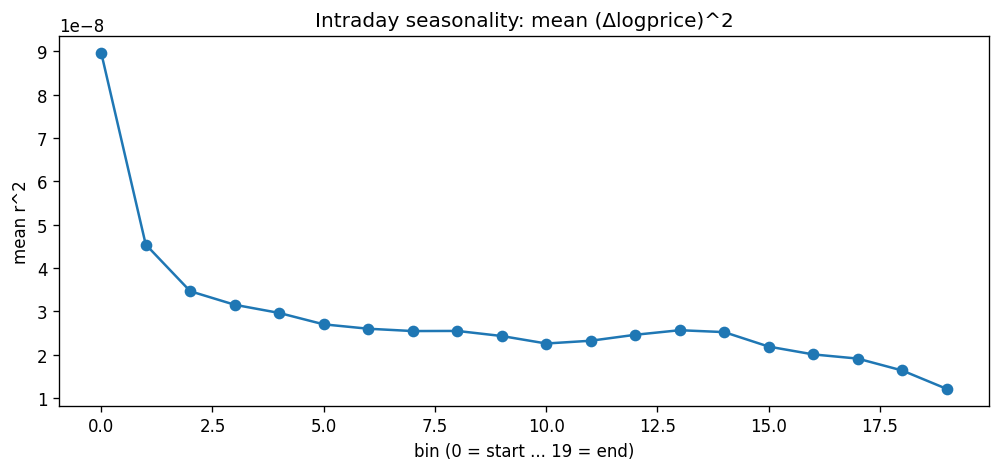

In [26]:
plt.figure()
plt.plot(season["ubin"], season["mean_sq"], marker="o")
plt.title("Intraday seasonality: mean (Δlogprice)^2")
plt.xlabel("bin (0 = start ... 19 = end)")
plt.ylabel("mean r^2")
plt.show()

The same pattern appears with squared returns (a volatility proxy): large at the beginning, then decreasing. This supports a clear **intraday seasonality** in volatility.


# 7) Daily extraction: quick summary


In [27]:
# Here we compute R_d and RV_d just to show what we can extract,
# and to add 2 complementary plots.

close = df.groupby("day")["logprice"].last()
R = close.diff().dropna().rename("R")

RV = (
    df.dropna(subset=["r_intraday"])
      .groupby("day")["r_intraday"]
      .apply(lambda x: np.sum(x.values**2))
      .rename("RV")
)

daily = pd.concat([R, RV], axis=1).dropna()


In [28]:
print("\n Extracted daily series (descriptive summary) :")
print(daily.describe())


 Extracted daily series (descriptive summary) :
                R          RV
count  753.000000  753.000000
mean     0.001212    0.000081
std      0.011100    0.000051
min     -0.036542    0.000016
25%     -0.004533    0.000051
50%      0.000886    0.000068
75%      0.007186    0.000095
max      0.056132    0.000507


Daily returns have mean close to zero and typical size around **1%** (std ≈ 0.011), while realized variance is small but variable across days. The max return and max RV confirm there are **a few high-volatility / big-move days**.


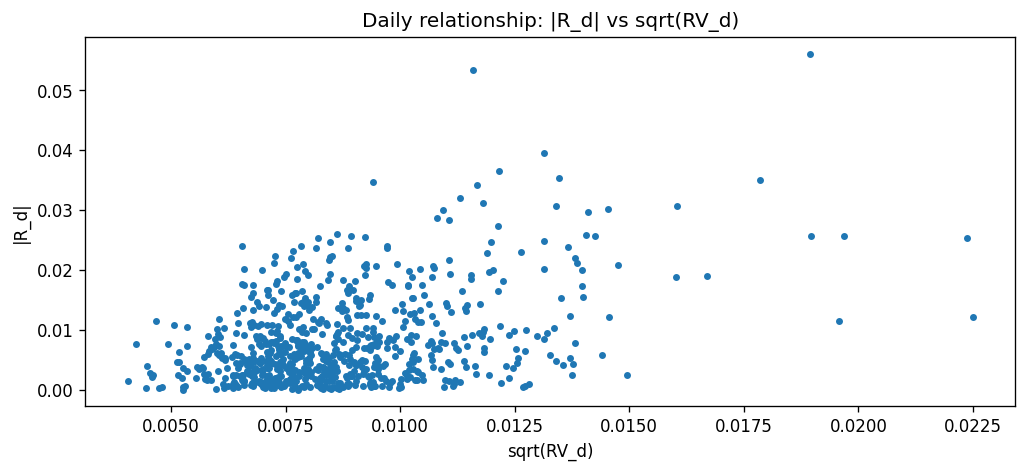

In [29]:

plt.figure()
plt.scatter(np.sqrt(daily["RV"].values), np.abs(daily["R"].values), s=10)
plt.title("Daily relationship: |R_d| vs sqrt(RV_d)")
plt.xlabel("sqrt(RV_d)")
plt.ylabel("|R_d|")
plt.show()

There is a positive relationship: days with higher realized volatility (x-axis) tend to have larger absolute daily returns (y-axis). It’s not perfect, but the ‘cloud’ widens as sqrt(RV) increases.


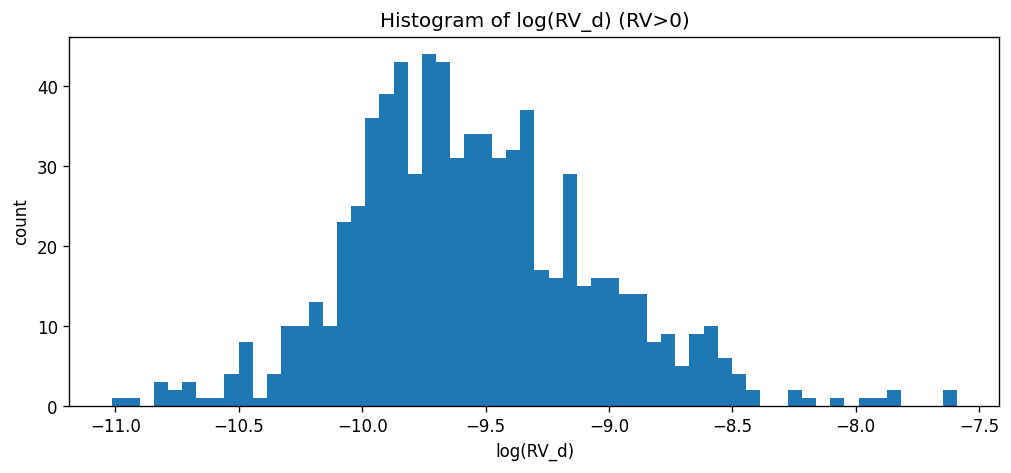

In [30]:
rv_pos = daily["RV"].values[daily["RV"].values > 0]
plt.figure()
plt.hist(np.log(rv_pos), bins=60)
plt.title("Histogram of log(RV_d) (RV>0)")
plt.xlabel("log(RV_d)")
plt.ylabel("count")
plt.show()

Taking logs makes the RV distribution easier to see: it looks roughly unimodal but skewed, with a right tail (some very volatile days). This is a quick way to show **heterogeneity in volatility levels** across days.


# 8) Global view of cumulative curves: heatmap


In [31]:
J_grid = 100
t_min = df["tick"].min()
t_max = df["tick"].max()
t_grid = np.linspace(t_min, t_max, J_grid)

days = np.sort(df["day"].unique())
Y = np.empty((len(days), J_grid))

In [32]:
for i, d in enumerate(days):
    sub = df[df["day"] == d]
    ticks = sub["tick"].to_numpy()
    prices = sub["logprice"].to_numpy()
    base = prices[0]
    idx = np.searchsorted(ticks, t_grid, side="right") - 1
    idx[idx < 0] = 0
    Y[i, :] = prices[idx] - base

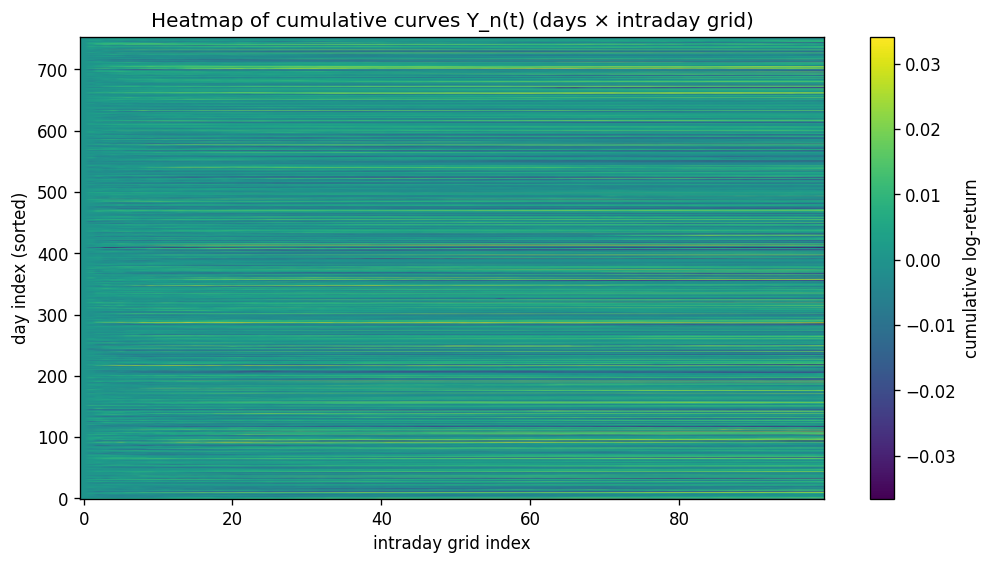

In [33]:
plt.figure(figsize=(10, 5))
plt.imshow(Y, aspect="auto", origin="lower")
plt.title("Heatmap of cumulative curves Y_n(t) (days × intraday grid)")
plt.xlabel("intraday grid index")
plt.ylabel("day index (sorted)")
plt.colorbar(label="cumulative log-return")
plt.show()

This heatmap shows the intraday cumulative log-return curves (Y_n(t)) for all days at once: each **row is a day** and each **column is a point on the intraday grid**. The color gives the cumulative return level (yellow = positive, purple = negative), and most days stay close to zero with a few days showing stronger upward or downward moves across the day.

